

2. Gramian Angular Field (GAF)

### 2.1 Concept

The **Gramian Angular Field** represents time series in the **polar coordinate system**, encoding the temporal correlations between each pair of time points as trigonometric relationships.

### 2.2 Mathematical Formulation

Let the original time series be:

$X = [x_1, x_2, \dots, x_n]$

#### Step 1. Normalization

Normalize the values to $[-1, 1]$:

$
\tilde{x}_i = \frac{x_i - \min(X)}{\max(X) - \min(X)} \times 2 - 1
$

#### Step 2. Polar Mapping

Convert each point to polar coordinates:

$
\phi_i = \arccos(\tilde{x}_i), \quad r_i = \frac{i}{n}
$

where $\phi_i$ is the angular component and $r_i$ is the radius proportional to time.

#### Step 3. Construct Gramian Matrix

There are two main variants:

- **GASF (Gramian Angular Summation Field):**
  $
  G_{i,j}^{\text{sum}} = \cos(\phi_i + \phi_j)
  = \tilde{x}_i \tilde{x}_j - \sqrt{1 - \tilde{x}_i^2}\sqrt{1 - \tilde{x}_j^2}
  $

- **GADF (Gramian Angular Difference Field):**
  $
  G_{i,j}^{\text{diff}} = \sin(\phi_i - \phi_j)
  = \tilde{x}_j \sqrt{1 - \tilde{x}_i^2} - \tilde{x}_i \sqrt{1 - \tilde{x}_j^2}
  $

The resulting $n \times n $ matrix can be visualized as an image, where pixel intensity encodes the angular correlation between time points $i$ and $j$.

### 2.3 Interpretation

- Diagonal elements $i=j$ represent the **self-correlation** of each time point.  
- Off-diagonal elements describe the **pairwise temporal relationships**.  
- GAF is sensitive to **trend and phase information** in the sequence.

---

## 3. Markov Transition Field (MTF)

### 3.1 Concept

The **Markov Transition Field** models the **probabilistic dynamics** of time series by encoding the transition probabilities between quantized states over time.

### 3.2 Mathematical Formulation

Let $ X = [x_1, x_2, \dots, x_n]$ be the original series.

#### Step 1. Discretization

Discretize the continuous series into Q  quantile-based states:

$
S = [s_1, s_2, \dots, s_n], \quad s_i \in \{1, 2, \dots, Q\}
$

#### Step 2. Transition Probability Matrix

Compute the first-order **Markov transition matrix**  P :

$
P_{i,j} = P(s_{t+1} = j \mid s_t = i)
$

#### Step 3. Construct the Markov Transition Field

For each pair of time indices $ (p, q) $:

$
MTF_{p,q} = P_{s_p, s_q}
$

This produces an $n \times n $ image where each pixel value corresponds to the transition probability between the states at time p and q.

### 3.3 Interpretation

- The diagonal reflects **self-transition** probabilities (stability).  
- Off-diagonal elements capture the **temporal co-occurrence** of state transitions.  
- MTF emphasizes the **dynamic behavior** of the system.

---

## 4. Comparison of GAF and MTF

| Feature | GAF (Gramian Angular Field) | MTF (Markov Transition Field) |
|----------|-----------------------------|-------------------------------|
| **Idea** | Polar coordinate + trigonometric correlation | Markov state transition probabilities |
| **Input Type** | Continuous time series | Discretized time series |
| **Output Matrix** | Angular correlation matrix | Transition probability matrix |
| **Captures** | Global phase and trend | Temporal dynamics and transition structure |
| **Diagonal Meaning** | Self-correlation | Self-transition probability |
| **Applications** | ECG/EEG, gesture recognition | Dynamic pattern recognition, behavior modeling |

---



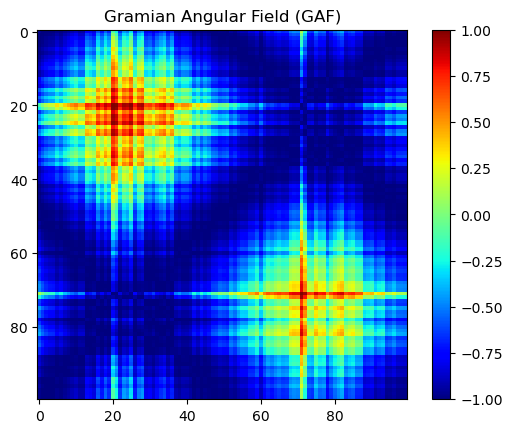

In [ ]:
import numpy as np
import matplotlib.pyplot as plt


t = np.linspace(0, 2*np.pi, 100)
x = np.sin(t) + 0.1*np.random.randn(100)

# 归一化到 [-1,1]
x_scaled = (x - np.min(x)) / (np.max(x) - np.min(x)) * 2 - 1
phi = np.arccos(x_scaled)

# 计算 GAF (cosine 版)
GAF = np.cos(phi[:, None] + phi[None, :])

plt.imshow(GAF, cmap='jet')
plt.title("Gramian Angular Field (GAF)")
plt.colorbar()
plt.show()


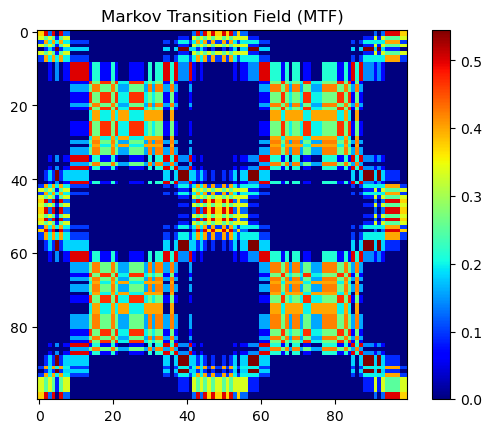

In [4]:
import numpy as np
import matplotlib.pyplot as plt

# 示例速度信号
x = np.abs(np.sin(np.linspace(0, 2*np.pi, 100)) + 0.1*np.random.randn(100))

# 1. 离散化到若干状态
num_bins = 8
bins = np.linspace(0, np.max(x), num_bins+1)
states = np.digitize(x, bins) - 1
# 🔧 修正：强制截断到合法范围 [0, num_bins-1]
states = np.clip(states, 0, num_bins-1)

# 2. 统计状态转移概率
P = np.zeros((num_bins, num_bins))
for i in range(len(states)-1):
    P[states[i], states[i+1]] += 1
P = P / (P.sum(axis=1, keepdims=True) + 1e-8)

# 3. 构建 MTF 图
MTF = np.zeros((len(states), len(states)))
for i in range(len(states)):
    for j in range(len(states)):
        MTF[i, j] = P[states[i], states[j]]

plt.imshow(MTF, cmap='jet')
plt.title("Markov Transition Field (MTF)")
plt.colorbar()
plt.show()


In [ ]:
import os
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt


DATA_ROOT = Path("Data/Balabit-dataset/training_files")


OUT_DIR = Path("analysis/session_event_distribution")
OUT_DIR.mkdir(parents=True, exist_ok=True)


In [ ]:
records = []

for user_dir in sorted(DATA_ROOT.iterdir()):
    if not user_dir.is_dir():
        continue

    user_id = user_dir.name

    for session_file in sorted(user_dir.iterdir()):
        if not session_file.is_file():
            continue

        try:
            df = pd.read_csv(session_file, sep=",", header=0)
            num_events = len(df)
        except Exception as e:
            print(f"[WARN] Failed to read {session_file}: {e}")
            continue

        records.append({
            "user": user_id,
            "session": session_file.name,
            "num_events": num_events
        })

df_sessions = pd.DataFrame(records)

print("Total sessions:", len(df_sessions))
df_sessions


Total sessions: 65


,user,session,num_events
0,user12,session_2144641057,30287
1,user12,session_5265929106,32322
2,user12,session_5815391283,48244
3,user12,session_7409188284,32652
4,user12,session_8872593360,33550
...,...,...,...
60,user9,session_3879637058,72732
61,user9,session_4373781904,56973
62,user9,session_5155383252,59781
63,user9,session_7285432516,57106


In [4]:
for user, df_user in df_sessions.groupby("user"):
    df_user = df_user.sort_values("num_events", ascending=False)

    plt.figure(figsize=(10, 4))
    plt.bar(df_user["session"], df_user["num_events"])
    plt.xticks(rotation=45, ha="right")
    plt.ylabel("Number of Events")
    plt.title(f"{user}: Event Count per Session")

    plt.tight_layout()
    plt.savefig(OUT_DIR / f"{user}_session_event_count.png", dpi=150)
    plt.close()

print(f"All plots saved to: {OUT_DIR.resolve()}")


All plots saved to: C:\Users\lijun\Mouse_Dynamics\analysis\session_event_distribution


In [5]:
summary = []

for user, df_user in df_sessions.groupby("user"):
    total_events = df_user["num_events"].sum()

    max_row = df_user.loc[df_user["num_events"].idxmax()]
    min_row = df_user.loc[df_user["num_events"].idxmin()]
    median_events = df_user["num_events"].median()

    summary.append({
        "user": user,
        "num_sessions": len(df_user),
        "total_events": total_events,
        "max_session": max_row["session"],
        "max_events": max_row["num_events"],
        "min_session": min_row["session"],
        "min_events": min_row["num_events"],
        "median_events": median_events,
        "max_ratio": max_row["num_events"] / total_events
    })

df_summary = pd.DataFrame(summary)
df_summary.sort_values("num_sessions")


,user,num_sessions,total_events,max_session,max_events,min_session,min_events,median_events,max_ratio
7,user35,5,98870,session_1909471574,23107,session_5394017914,16901,19415.0,0.233711
1,user15,6,149921,session_6715291950,44018,session_5657866014,16971,20517.0,0.293608
2,user16,6,240046,session_0735651357,53816,session_6961018175,28428,37619.0,0.224190
5,user23,6,124548,session_9962419470,28435,session_3195683016,17127,20027.5,0.228306
0,user12,7,246824,session_5815391283,48244,session_9838420452,29722,32652.0,0.195459
3,user20,7,294197,session_2372891077,60087,session_7888368102,31441,39131.0,0.204241
4,user21,7,125931,session_5306911480,21465,session_7767882493,15342,17636.0,0.170450
6,user29,7,131751,session_3424156599,32601,session_2786719181,13640,15524.0,0.247444
8,user7,7,426060,session_0041905381,83091,session_1060325796,43484,59197.0,0.195022
9,user9,7,415668,session_3879637058,72732,session_0335985747,54418,57106.0,0.174976


In [6]:
import os
import itertools
import numpy as np

# ======================================================
# MODIFY IF NEEDED
# ======================================================
DATA_ROOT = "Data/Balabit-dataset/training_files"


def count_events_in_session(file_path):
    """
    Count events in ONE session file.
    Assumes:
      - plain text
      - first line = header
      - one event per line
    """
    with open(file_path, "r", encoding="utf-8", errors="ignore") as f:
        line_count = sum(1 for _ in f)

    # remove header
    return max(0, line_count - 1)


def load_user_sessions(data_root):
    """
    Build:
        user_sessions[user] = [event_cnt_session1, session2, ...]
    """
    user_sessions = {}

    for user in sorted(os.listdir(data_root)):
        user_dir = os.path.join(data_root, user)
        if not os.path.isdir(user_dir):
            continue

        session_events = []

        for sess_file in sorted(os.listdir(user_dir)):
            sess_path = os.path.join(user_dir, sess_file)
            if not os.path.isfile(sess_path):
                continue

            ev_cnt = count_events_in_session(sess_path)
            session_events.append(ev_cnt)

        if session_events:
            user_sessions[user] = session_events

    return user_sessions


def average_loso_event_ratio(user_sessions):
    """
    LOSO average train/test split ratio (EVENT LEVEL)
    """
    users = list(user_sessions.keys())

    # each user chooses 1 session index as test
    choices = [list(range(len(user_sessions[u]))) for u in users]

    ratios = []

    for test_indices in itertools.product(*choices):
        train_events = 0
        test_events = 0

        for u, test_idx in zip(users, test_indices):
            for i, ev in enumerate(user_sessions[u]):
                if i == test_idx:
                    test_events += ev
                else:
                    train_events += ev

        ratios.append(train_events / (train_events + test_events))

    return float(np.mean(ratios))


# ======================================================
# MAIN
# ======================================================
if __name__ == "__main__":
    user_sessions = load_user_sessions(DATA_ROOT)

    print("=== Per-user session statistics (event-level) ===")
    for u, sess in user_sessions.items():
        print(f"{u}: {len(sess)} sessions | total events = {sum(sess)}")

    avg_ratio = average_loso_event_ratio(user_sessions)

    print("\n=== LOSO EVENT-LEVEL SPLIT ===")
    print(f"Average Train Ratio : {avg_ratio:.6f}")
    print(f"Average Test  Ratio : {1 - avg_ratio:.6f}")


=== Per-user session statistics (event-level) ===
user12: 7 sessions | total events = 246824
user15: 6 sessions | total events = 149921
user16: 6 sessions | total events = 240046
user20: 7 sessions | total events = 294197
user21: 7 sessions | total events = 125931
user23: 6 sessions | total events = 124548
user29: 7 sessions | total events = 131751
user35: 5 sessions | total events = 98870
user7: 7 sessions | total events = 426060
user9: 7 sessions | total events = 415668

=== LOSO EVENT-LEVEL SPLIT ===
Average Train Ratio : 0.849201
Average Test  Ratio : 0.150799


正在扫描 (无后缀文件模式): Data\Balabit-dataset\testing_files_protocol1 ...

统计结果 (Protocol 1):
检测到会话数: 411
最小长度:     132
最大长度:     9988
平均长度:     1506.23
中位数:       1052.00


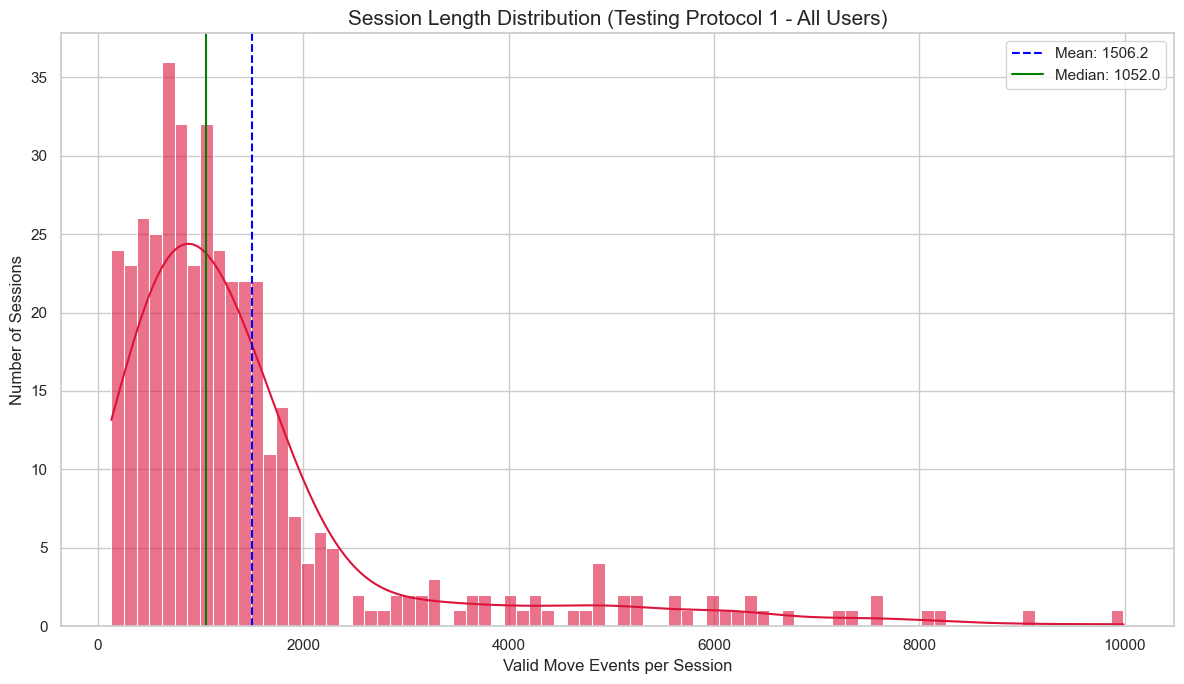

In [2]:
# -*- coding: utf-8 -*-
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ============================================================
# 路径配置：脚本在根目录运行
# ============================================================
# 自动定位到 Data/Balabit-dataset/testing_files_protocol1
DATA_PATH = os.path.join("Data", "Balabit-dataset", "testing_files_protocol1")

# ============================================================
# 数据读取与清洗逻辑
# ============================================================
def get_cleaned_session_length(file_path):
    """读取无后缀的 session 文件并返回清洗后的有效事件数量"""
    try:
        # 直接读取，不检查后缀
        df = pd.read_csv(file_path)
        
        # 统一重命名（适配截图中的列名）
        rename_dict = {
            "client timestamp": "time",
            "x": "x",
            "y": "y",
            "state": "state"
        }
        df = df.rename(columns=rename_dict)

        # 1. 仅保留 Move 状态 (过滤掉可能存在的 Pressed/Released 等)
        if "state" in df.columns:
            df = df[df["state"] == "Move"].copy()
        
        # 2. 强制转换数值，处理可能存在的脏数据
        df["x"] = pd.to_numeric(df["x"], errors="coerce")
        df["y"] = pd.to_numeric(df["y"], errors="coerce")
        
        # 3. 核心清洗：剔除 65535 异常值行
        mask_valid = (df["x"] < 65535) & (df["y"] < 65535)
        df = df[mask_valid].dropna(subset=["x", "y"])
        
        return len(df)
    except Exception as e:
        # 打印错误以防万一
        # print(f"无法读取文件 {os.path.basename(file_path)}: {e}")
        return 0

# ============================================================
# 主程序：遍历并绘图
# ============================================================
def main():
    session_lengths = []
    
    if not os.path.exists(DATA_PATH):
        print(f"[错误] 找不到路径: {DATA_PATH}")
        print("请检查：1. 脚本是否在项目根目录？ 2. 路径拼写是否正确？")
        return

    print(f"正在扫描 (无后缀文件模式): {DATA_PATH} ...")

    # 遍历所有子目录
    for root, dirs, files in os.walk(DATA_PATH):
        for name in files:
            # 修正逻辑：只检查 session_ 前缀，不检查后缀
            if name.startswith("session_"):
                file_path = os.path.join(root, name)
                length = get_cleaned_session_length(file_path)
                if length > 0:
                    session_lengths.append(length)

    if not session_lengths:
        print("未提取到有效数据。请确认目录下是否存在 session_ 开头的文件。")
        return

    # --- 绘制直方图 ---
    plt.figure(figsize=(12, 7))
    sns.set(style="whitegrid")
    
    # 绘制分布图
    sns.histplot(session_lengths, bins=80, kde=True, color='crimson', alpha=0.6)
    
    # 统计指标
    mean_val = np.mean(session_lengths)
    median_val = np.median(session_lengths)
    
    plt.axvline(mean_val, color='blue', linestyle='--', label=f'Mean: {mean_val:.1f}')
    plt.axvline(median_val, color='green', linestyle='-', label=f'Median: {median_val:.1f}')

    plt.title('Session Length Distribution (Testing Protocol 1 - All Users)', fontsize=15)
    plt.xlabel('Valid Move Events per Session', fontsize=12)
    plt.ylabel('Number of Sessions', fontsize=12)
    plt.legend()
    
    # 输出结果
    print("\n" + "="*45)
    print(f"统计结果 (Protocol 1):")
    print(f"检测到会话数: {len(session_lengths)}")
    print(f"最小长度:     {min(session_lengths)}")
    print(f"最大长度:     {max(session_lengths)}")
    print(f"平均长度:     {mean_val:.2f}")
    print(f"中位数:       {median_val:.2f}")
    print("="*45)

    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    main()

In [6]:
import os
import pandas as pd

# =============================
# 路径
# =============================
PROJECT_ROOT = os.path.abspath("")
DATA_ROOT = os.path.join(PROJECT_ROOT, "Data", "Balabit-dataset")

TEST_ROOT = os.path.join(DATA_ROOT, "testing_files_protocol2")
CSV_PATH = os.path.join(DATA_ROOT, "public_labels.csv")

# =============================
# 1️⃣ 读取 CSV
# =============================
df = pd.read_csv(CSV_PATH)
csv_sessions = set(df["filename"].astype(str))

print("CSV total sessions:", len(csv_sessions))

# =============================
# 2️⃣ 收集 Protocol2 session
# =============================
protocol_sessions = set()

def collect_sessions(base_folder):
    for user in os.listdir(base_folder):
        user_path = os.path.join(base_folder, user)
        if not os.path.isdir(user_path):
            continue

        for fname in os.listdir(user_path):
            # 这里不判断后缀，直接收集
            protocol_sessions.add(fname)

collect_sessions(os.path.join(TEST_ROOT, "genuine"))
collect_sessions(os.path.join(TEST_ROOT, "imposter"))

print("Protocol2 unique sessions:", len(protocol_sessions))

# =============================
# 3️⃣ 对比
# =============================
only_in_csv = csv_sessions - protocol_sessions
only_in_protocol = protocol_sessions - csv_sessions

print("\nSessions only in CSV:", len(only_in_csv))
print("Sessions only in Protocol2:", len(only_in_protocol))

if len(only_in_csv) > 0:
    print("Example (CSV only):", list(only_in_csv)[:5])

if len(only_in_protocol) > 0:
    print("Example (Protocol2 only):", list(only_in_protocol)[:5])

if len(only_in_csv) == 0 and len(only_in_protocol) == 0:
    print("\n✅ 完全一致")
else:
    print("\n❌ 不一致")

CSV total sessions: 816
Protocol2 unique sessions: 816

Sessions only in CSV: 0
Sessions only in Protocol2: 0

✅ 完全一致


In [7]:
import os

PROJECT_ROOT = os.path.abspath("")
DATA_ROOT = os.path.join(PROJECT_ROOT, "Data", "Balabit-dataset")

TEST_FILES_ROOT = os.path.join(DATA_ROOT, "test_files")
PROTOCOL2_ROOT = os.path.join(DATA_ROOT, "testing_files_protocol2")

# =============================
# 1️⃣ 收集 test_files 里的 session
# =============================
test_sessions = set()

for user in os.listdir(TEST_FILES_ROOT):
    user_path = os.path.join(TEST_FILES_ROOT, user)
    if not os.path.isdir(user_path):
        continue

    for fname in os.listdir(user_path):
        test_sessions.add(fname)

print("test_files unique sessions:", len(test_sessions))

# =============================
# 2️⃣ 收集 protocol2 里的 session
# =============================
protocol2_sessions = set()

def collect_protocol2_sessions(base_folder):
    for user in os.listdir(base_folder):
        user_path = os.path.join(base_folder, user)
        if not os.path.isdir(user_path):
            continue

        for fname in os.listdir(user_path):
            protocol2_sessions.add(fname)

collect_protocol2_sessions(os.path.join(PROTOCOL2_ROOT, "genuine"))
collect_protocol2_sessions(os.path.join(PROTOCOL2_ROOT, "imposter"))

print("protocol2 unique sessions:", len(protocol2_sessions))

# =============================
# 3️⃣ 对比
# =============================
only_in_test = test_sessions - protocol2_sessions
only_in_protocol2 = protocol2_sessions - test_sessions

print("\nSessions only in test_files:", len(only_in_test))
print("Sessions only in protocol2:", len(only_in_protocol2))

if len(only_in_test) > 0:
    print("Example (only in test_files):", list(only_in_test)[:5])

if len(only_in_protocol2) > 0:
    print("Example (only in protocol2):", list(only_in_protocol2)[:5])

if len(only_in_test) == 0 and len(only_in_protocol2) == 0:
    print("\n✅ 完全一致：Protocol2 和 test_files session 集合相同")
else:
    print("\n❌ 不一致：看上面差异")

test_files unique sessions: 1611
protocol2 unique sessions: 816

Sessions only in test_files: 795
Sessions only in protocol2: 0
Example (only in test_files): ['session_9838364022', 'session_1574713570', 'session_8963903506', 'session_8847581248', 'session_0017454856']

❌ 不一致：看上面差异


In [9]:
import os

ROOT = "Images/SRP_224_protocol2"

def count_images_in_folder(folder_path):
    total = 0
    for root, dirs, files in os.walk(folder_path):
        for f in files:
            if f.lower().endswith((".png", ".jpg", ".jpeg")):
                total += 1
    return total


genuine_path = os.path.join(ROOT, "genuine", "event60")
imposter_path = os.path.join(ROOT, "imposter", "event60")

genuine_count = count_images_in_folder(genuine_path)
imposter_count = count_images_in_folder(imposter_path)

print("="*60)
print(f"Genuine total images  : {genuine_count}")
print(f"Imposter total images : {imposter_count}")
print(f"Overall total images  : {genuine_count + imposter_count}")
print("="*60)

Genuine total images  : 10103
Imposter total images : 5693
Overall total images  : 15796


## Plot Training Global Distribution

In [4]:
import numpy as np
import matplotlib.pyplot as plt

'''
def plot_global_distribution(
    values,
    percentile=95,
    bins=500,
    title="Global Distribution",
    xlabel="Value",
    save_path=None
):
    """
    Plot global distribution with symmetric percentile bound.

    Parameters
    ----------
    values : np.ndarray
        1D array of distribution values (e.g., acceleration, velocity)
    percentile : float
        Symmetric percentile bound (default 95)
    bins : int
        Histogram bins
    title : str
        Plot title
    xlabel : str
        X-axis label
    save_path : str or None
        If provided, saves the figure
    """

    values = np.asarray(values).flatten()

    print("====================================")
    print("Total samples:", len(values))
    print("Min:", values.min())
    print("Max:", values.max())
    print("Mean:", values.mean())
    print("Median:", np.median(values))
    print("Std:", values.std())

    # symmetric percentile bound
    max_abs = np.percentile(np.abs(values), percentile)

    print(f"\nSymmetric {percentile}% bound (|x|):", max_abs)
    print("====================================\n")

    # Plot
    plt.figure(figsize=(8, 5))

    plt.hist(
        values,
        bins=bins,
        density=True,
        alpha=0.7
    )

    plt.axvline(0, linestyle="--")
    plt.axvline(max_abs, linestyle="--")
    plt.axvline(-max_abs, linestyle="--")

    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel("Density")

    plt.xlim(-max_abs * 1.5, max_abs * 1.5)

    plt.tight_layout()

    if save_path is not None:
        plt.savefig(save_path, dpi=300)
        print(f"Figure saved to: {save_path}")

    plt.show()

    return max_abs
'''

import numpy as np
import matplotlib.pyplot as plt


def plot_global_distribution(
    values,
    percentile=95,
    bins=500,
    title="Global Distribution",
    xlabel="Value",
    mode="symmetric",   # "symmetric" or "one_sided"
    save_path=None
):
    """
    Plot global distribution with configurable clipping.

    Parameters
    ----------
    values : np.ndarray
        1D array of distribution values
    percentile : float
        Percentile bound
    bins : int
        Histogram bins
    title : str
        Plot title
    xlabel : str
        X-axis label
    mode : str
        "symmetric"  -> clip ±percentile
        "one_sided"  -> clip only right side (0 → percentile)
    save_path : str or None
        If provided, saves the figure
    """

    values = np.asarray(values).flatten()

    print("====================================")
    print("Total samples:", len(values))
    print("Min:", values.min())
    print("Max:", values.max())
    print("Mean:", values.mean())
    print("Median:", np.median(values))
    print("Std:", values.std())

    # --------------------------------------------------
    # Determine clipping
    # --------------------------------------------------
    if mode == "symmetric":

        max_abs = np.percentile(np.abs(values), percentile)

        print(f"\nSymmetric {percentile}% bound (|x|):", max_abs)

        clip_left = -max_abs
        clip_right = max_abs
        xlim_left = -max_abs * 1.5
        xlim_right = max_abs * 1.5

    elif mode == "one_sided":

        max_val = np.percentile(values, percentile)

        print(f"\nOne-sided {percentile}% bound:", max_val)

        clip_left = 0
        clip_right = max_val
        xlim_left = 0
        xlim_right = max_val * 1.5

    else:
        raise ValueError("mode must be 'symmetric' or 'one_sided'")

    print("====================================\n")

    # --------------------------------------------------
    # Plot
    # --------------------------------------------------
    plt.figure(figsize=(8, 5))

    plt.hist(
        values,
        bins=bins,
        density=True,
        alpha=0.7
    )

    plt.axvline(clip_left, linestyle="--")
    plt.axvline(clip_right, linestyle="--")

    if mode == "symmetric":
        plt.axvline(0, linestyle="--")

    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel("Density")

    plt.xlim(xlim_left, xlim_right)

    plt.tight_layout()

    if save_path is not None:
        plt.savefig(save_path, dpi=300)
        print(f"Figure saved to: {save_path}")

    plt.show()

    return clip_right

Total samples: 1926971
Min: 0.0
Max: 9229944596.258419
Mean: 393282.9458580024
Median: 204.2927732226993
Std: 46869717.625409715

One-sided 95% bound: 538516.4807134503



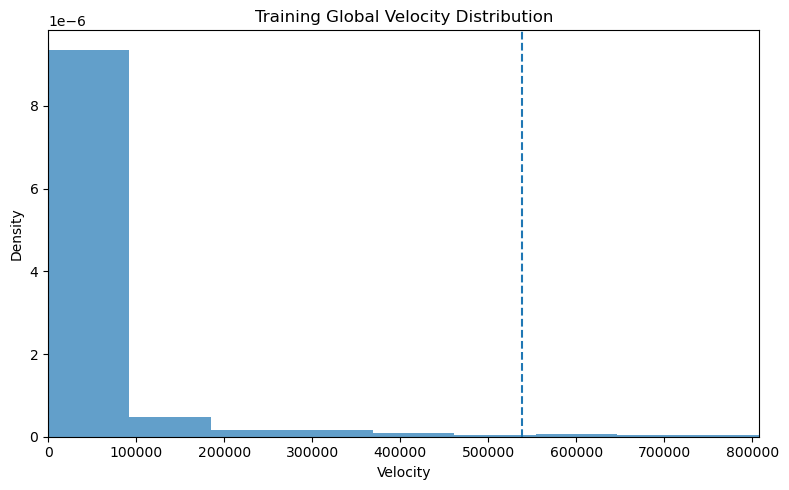

In [7]:
data = np.load("velocity_distribution_raw.npz")
acc = data["velocities"]

bound = plot_global_distribution(
    acc,
    percentile=95,
    bins=100000,
    mode= "one_sided",
    title="Training Global Velocity Distribution",
    xlabel="Velocity"
)

Total samples: 56778060
Min: 0.0
Max: 7916.723000000001
Mean: 6.641316246469146
Median: 1.2010000000000218
Std: 68.45163697823918

One-sided 95% bound: 16.878999999999905



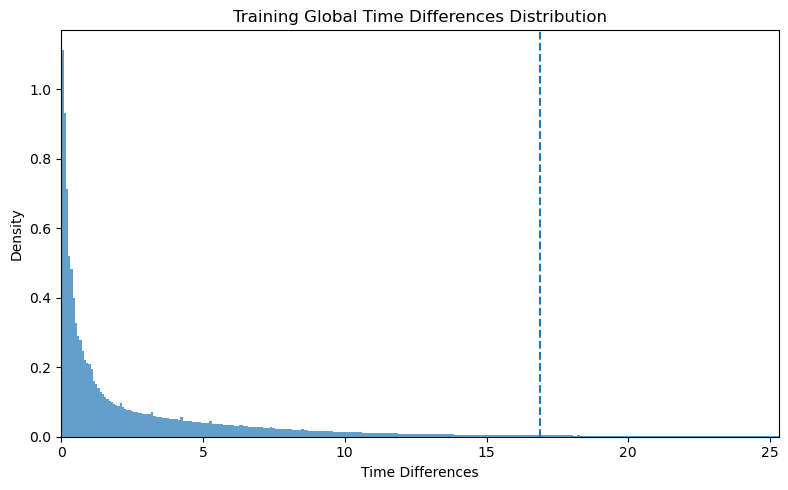

In [8]:
data = np.load("time_difference_distribution_raw.npz")
acc = data["time_differences"]

bound = plot_global_distribution(
    acc,
    percentile=95,
    bins=100000,
    mode = "one_sided",
    title="Training Global Time Differences Distribution",
    xlabel="Time Differences"
)

Total samples: 1664638
Min: 0.01499999959999343
Max: 6757.027
Mean: 0.38296106360662174
Median: 0.09400000000096043
Std: 15.509939011658803

One-sided 95% bound: 0.5149999999998727



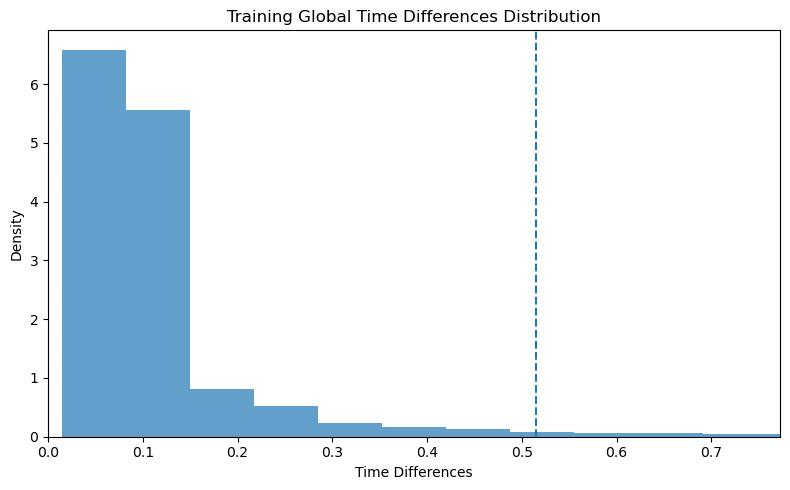

In [9]:
data = np.load("time_difference_space_distribution_raw.npz")
acc = data["time_differences"]

bound = plot_global_distribution(
    acc,
    percentile=95,
    bins=100000,
    mode="one_sided",
    title="Training Global Time Differences Distribution",
    xlabel="Time Differences"
)

Total samples: 143196450
Min: 0.0
Max: 9229944596.197832
Mean: 756701.1885821545
Median: 384.2621348307845
Std: 66309107.92784597

Symmetric 90% bound (|x|): 412170.80831317295



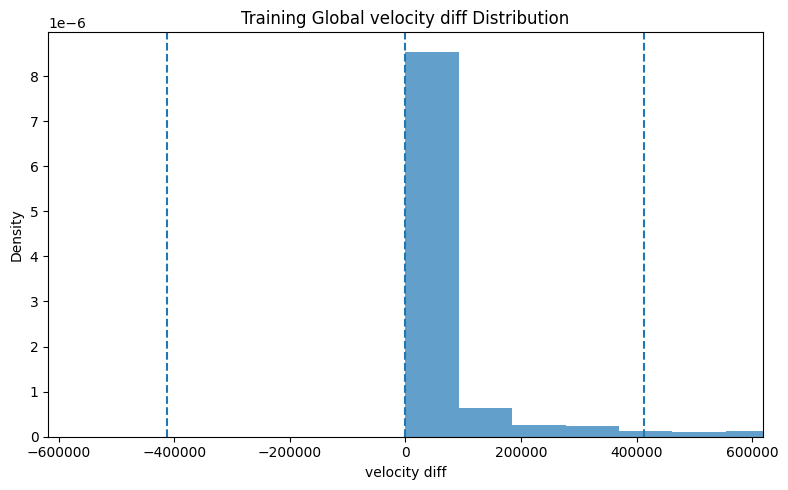

In [ ]:
import numpy as np
data = np.load("Balabit_velocity_diff_distribution_raw.npz")

vx = data["values"]

bound = plot_global_distribution(
    vx,
    percentile=90,
    bins=100000,
    title="Training Global velocity diff Distribution",
    xlabel="velocity diff"
)

Total samples: 1926971
Min: -6530599999.999999
Max: 163000000.0
Mean: -171803.08793482385
Median: 0.0
Std: 33180979.686712276

Symmetric 95% bound (|x|): 300000.0



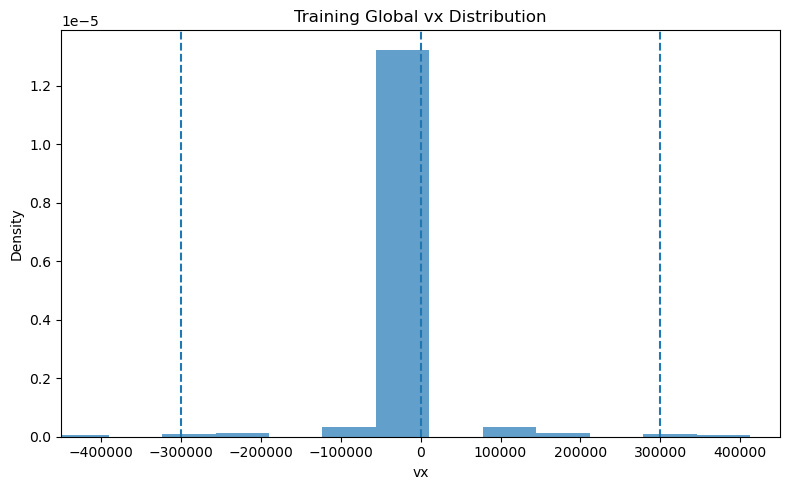

In [10]:
import numpy as np
data = np.load("vx_vy_distribution_raw.npz")

vx = data["vx"]

bound = plot_global_distribution(
    vx,
    percentile=95,
    bins=100000,
    title="Training Global vx Distribution",
    xlabel="vx"
)

Total samples: 1926971
Min: -6552399999.999999
Max: 107899999.99999999
Mean: -164725.66759730893
Median: 0.0
Std: 33104245.013963725

Symmetric 95% bound (|x|): 199999.99999999997



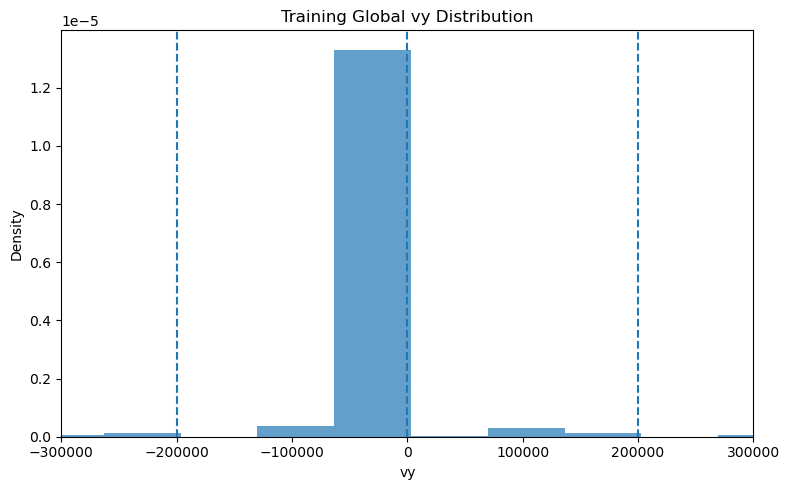

In [11]:
data = np.load("vx_vy_distribution_raw.npz")

vy = data["vy"]

bound = plot_global_distribution(
    vy,
    percentile=95,
    bins=100000,
    title="Training Global vy Distribution",
    xlabel="vy"
)

Total samples: 50391182
Min: 0.0
Max: 141636471.29182512
Mean: 1170.595366472832
Median: 0.1111111111111111
Std: 159427.10596823224

One-sided 95% bound: 2.0124611797498106



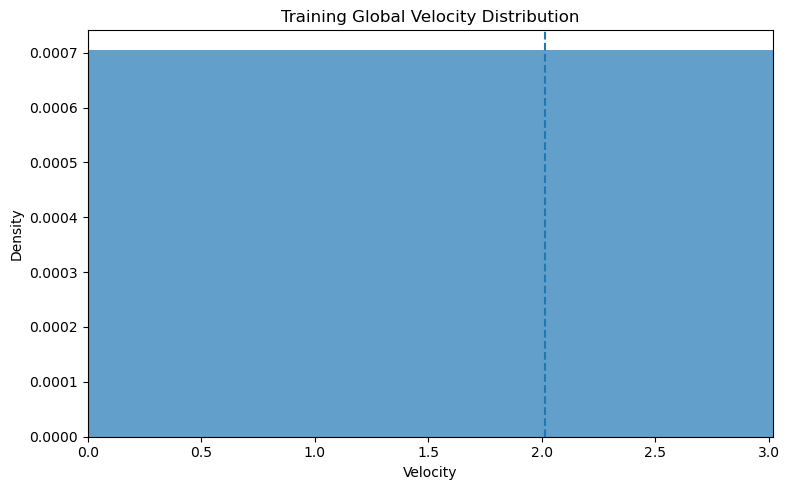

In [13]:
data = np.load("ChaoShen_velocity_distribution_raw.npz")
acc = data["velocities"]

bound = plot_global_distribution(
    acc,
    percentile=95,
    bins=100000,
    mode = "one_sided",
    title="Training Global Velocity Distribution",
    xlabel="Velocity"
)

Total samples: 50391182
Min: -111699999.99999999
Max: 111699999.99999999
Mean: 23.18019720930099
Median: 0.0
Std: 121802.59251682855

Symmetric 95% bound (|x|): 1.5



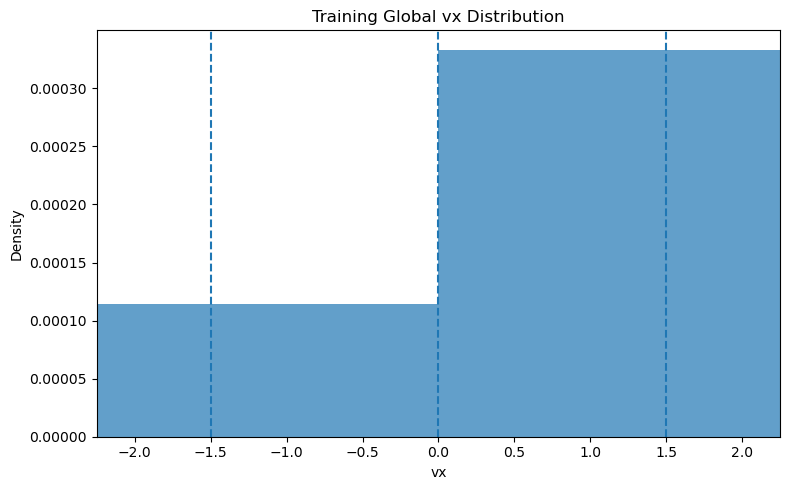

In [14]:
data = np.load("ChaoShen_vx_vy_distribution_raw.npz")

vx = data["vx"]

bound = plot_global_distribution(
    vx,
    percentile=95,
    bins=100000,
    title="Training Global vx Distribution",
    xlabel="vx"
)

Total samples: 50391182
Min: -11170000000.0
Max: 11170000000.0
Mean: 2317.61851448572
Median: 0.0
Std: 12180259.388496015

Symmetric 97.5% bound (|x|): 2399.999999998772



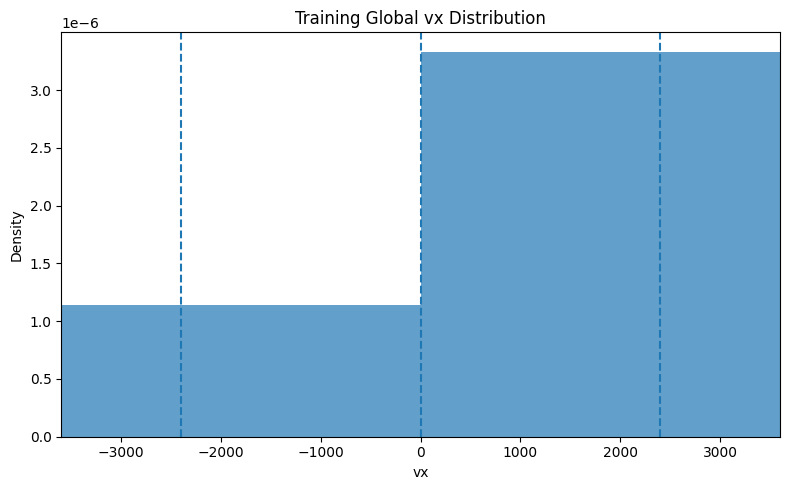

In [3]:
data = np.load("ChaoShen_vx_vy_distribution_raw.npz")

vx = data["vx"]

bound = plot_global_distribution(
    vx,
    percentile=97.5,
    bins=100000,
    title="Training Global vx Distribution",
    xlabel="vx"
)

Total samples: 50391182
Min: -11170000000.0
Max: 11170000000.0
Mean: 2318.063853639505
Median: 0.0
Std: 12180259.250293395

Symmetric 95% bound (|x|): 1.5



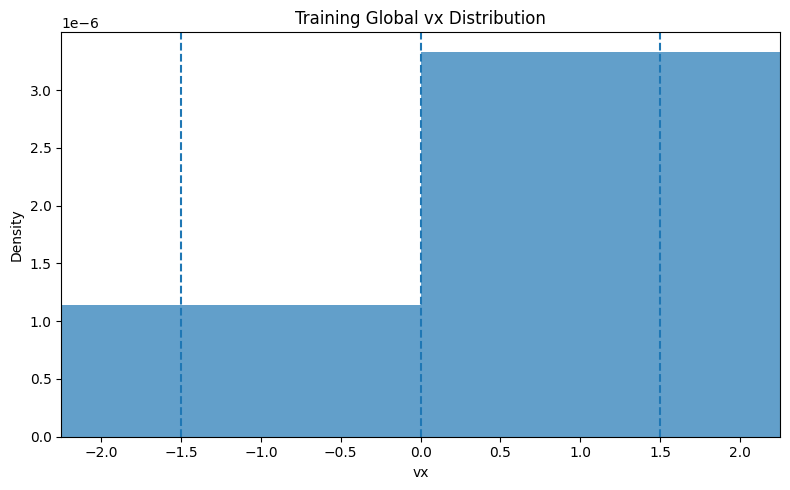

In [4]:
data = np.load("ChaoShen_vx_vy_distribution_raw.npz")

vx = data["vx"]

bound = plot_global_distribution(
    vx,
    percentile=95,
    bins=100000,
    title="Training Global vx Distribution",
    xlabel="vx"
)

Total samples: 50391182
Min: 0.0
Max: 14163647129.182512
Mean: 117012.37429554488
Median: 0.1111111111111111
Std: 15942710.941162078

One-sided 95% bound: 2.0124611797498106



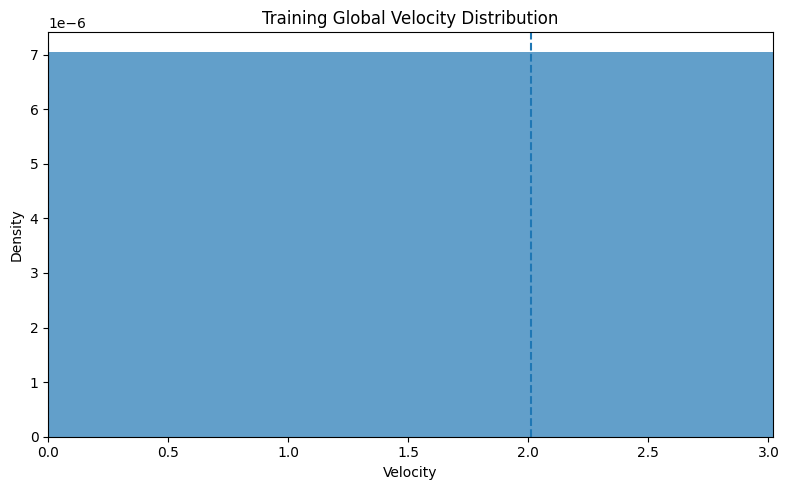

In [3]:
data = np.load("ChaoShen_velocity_distribution_raw.npz")
acc = data["values"]

bound = plot_global_distribution(
    acc,
    percentile=95,
    bins=100000,
    mode = "one_sided",
    title="Training Global Velocity Distribution",
    xlabel="Velocity"
)

Total samples: 50391182
Min: -100799999.99999999
Max: 100799999.99999999
Mean: -14.713146022008928
Median: 0.0
Std: 102871.27934121992

Symmetric 95% bound (|x|): 1.2



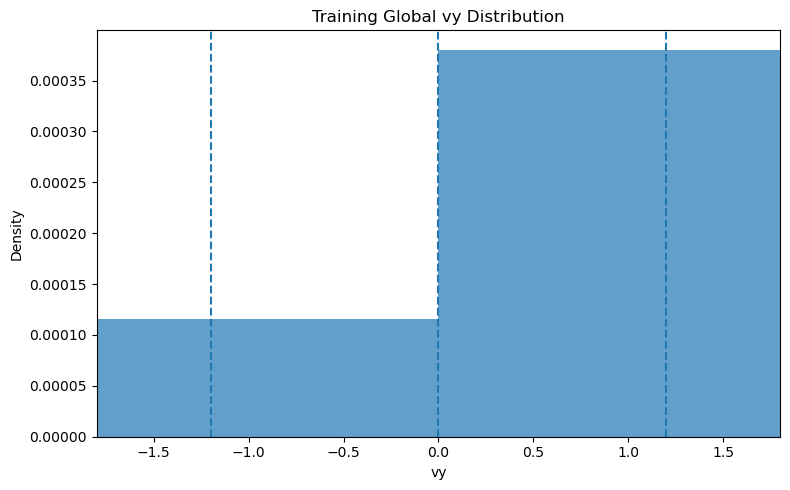

In [15]:
data = np.load("ChaoShen_vx_vy_distribution_raw.npz")

vy = data["vy"]

bound = plot_global_distribution(
    vy,
    percentile=95,
    bins=100000,
    title="Training Global vy Distribution",
    xlabel="vy"
)

Total samples: 1485957480
Min: 0.0
Max: 215872130.0
Mean: 2923.4128
Median: 160.0
Std: 225498.45

One-sided 95% bound: 3117.0



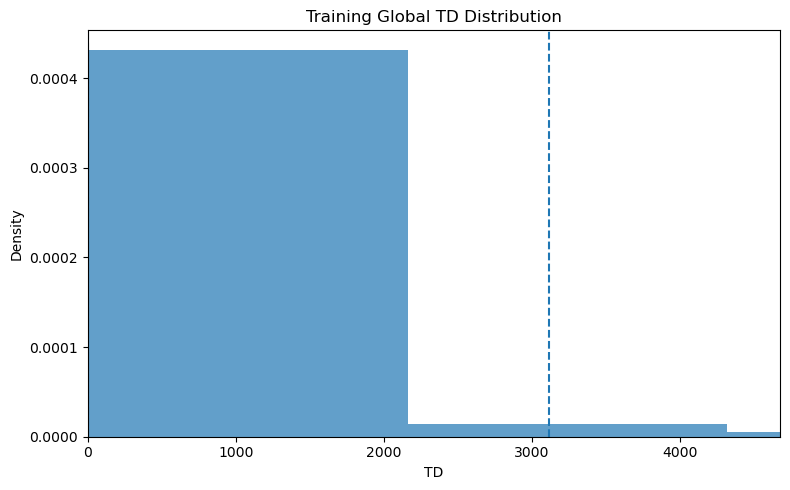

In [13]:
data = np.load("ChaoShen_time_difference_distribution_raw.npz")

v = data['time_differences']

bound = plot_global_distribution(
    v,
    percentile=95,
    bins=100000,
    mode = "one_sided",
    title="Training Global TD Distribution",
    xlabel="TD"
)

## DFL

Total samples: 87497036
Min: 0.0
Max: 549937132.7706468
Mean: 20823.520257160297
Median: 0.5153882032022076
Std: 307243.726656285

One-sided 95% bound: 7.883923515610739



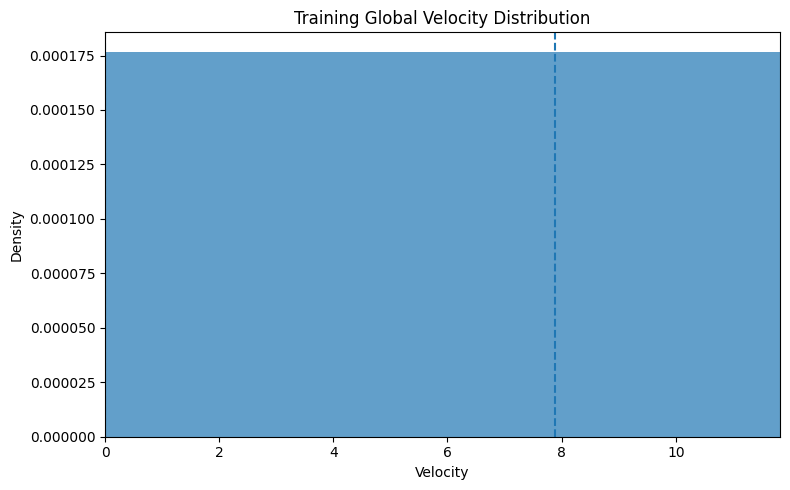

In [6]:
data = np.load("DFL_velocity_distribution_raw.npz")

v = data['values']

bound = plot_global_distribution(
    v,
    percentile=95,
    bins=100000,
    mode = "one_sided",
    title="Training Global Velocity Distribution",
    xlabel="Velocity"
)

Total samples: 87497036
Min: -331500000.0
Max: 338000000.0
Mean: 7.884697105565883
Median: 0.0
Std: 174910.98292132234

Symmetric 95% bound (|x|): 4.0



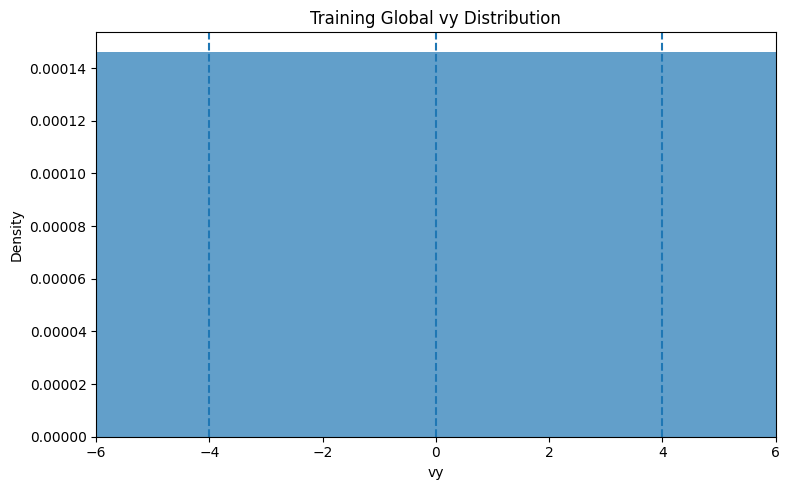

In [7]:
data = np.load("DFL_vx_vy_distribution_raw.npz")

vy = data["vy"]

bound = plot_global_distribution(
    vy,
    percentile=95,
    bins=100000,
    title="Training Global vy Distribution",
    xlabel="vy"
)

Total samples: 87497036
Min: -537800000.0
Max: 390699999.99999994
Mean: -145.57606920274628
Median: 0.0
Std: 253453.05948928487

Symmetric 95% bound (|x|): 6.0



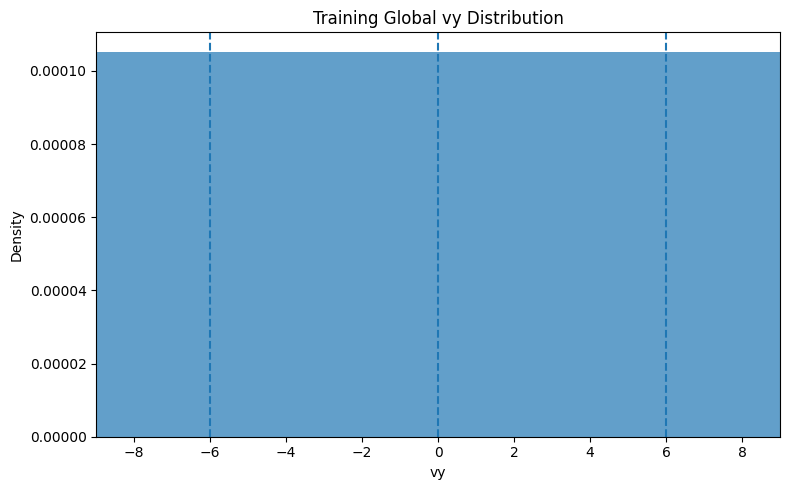

In [3]:
data = np.load("DFL_vx_vy_distribution_raw.npz")

vx = data["vx"]

bound = plot_global_distribution(
    vx,
    percentile=95,
    bins=100000,
    title="Training Global vy Distribution",
    xlabel="vy"
)

In [16]:
import cv2
old = cv2.imread("Images/ChaoShen/SRP/event60/user1/session_1-0.png", 0)
new = cv2.imread("Images/ChaoShen/SRP_/event60/user1/session_1-0.png", 0)

print(np.abs(old - new).max())
diff = np.abs(old.astype(int) - new.astype(int))

print("max diff:", diff.max())
print("mean diff:", diff.mean())
print("nonzero pixels:", np.count_nonzero(diff))

255
max diff: 42
mean diff: 1.336734693877551
nonzero pixels: 20506


session: session_1
user: 0


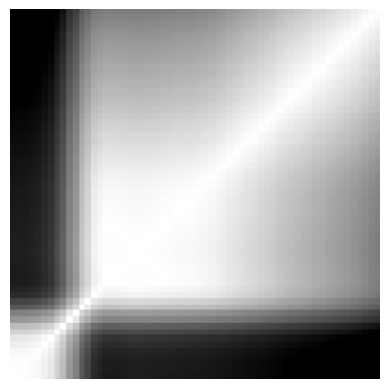

In [2]:
import numpy as np
import os
import matplotlib.pyplot as plt

dataset_root = "Images/Tensors/ChaoShen/SRP"

# 读取第一张图
with open(os.path.join(dataset_root, "images.npy"), "rb") as f:
    img = np.fromfile(f, dtype=np.uint8, count=224*224)

img = img.reshape(224,224)

# labels 只读第一行
with open(os.path.join(dataset_root,"labels.npy"),"rb") as f:
    label = np.fromfile(f,dtype=np.uint8,count=28)

sessions = np.load(
    os.path.join(dataset_root,"sessions.npy"),
    allow_pickle=True
)

print("session:",sessions[0])
print("user:",np.argmax(label))

plt.imshow(img,cmap="gray")
plt.axis("off")
plt.show()

session: session_670
user: 27


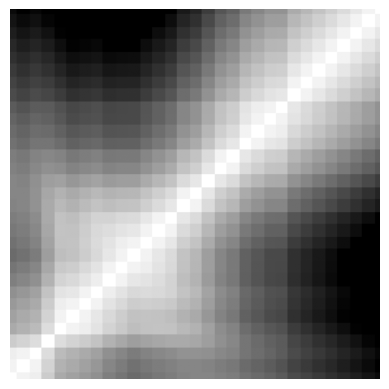

In [ ]:
import numpy as np
import os
import matplotlib.pyplot as plt

dataset_root = "ImagesTensors/ChaoShen/SRP"

N = 839524
H = 224
W = 224
U = 28

# =========================
# last image
# =========================

with open(os.path.join(dataset_root, "images.npy"), "rb") as f:

    f.seek((N-1) * H * W)  
    img = np.fromfile(f, dtype=np.uint8, count=H*W)

img = img.reshape(H,W)

# =========================
# label
# =========================

with open(os.path.join(dataset_root, "labels.npy"), "rb") as f:

    f.seek((N-1) * U)
    label = np.fromfile(f, dtype=np.uint8, count=U)

# =========================
# session
# =========================

sessions = np.load(
    os.path.join(dataset_root,"sessions.npy"),
    allow_pickle=True
)

print("session:", sessions[-1])
print("user:", np.argmax(label))



plt.imshow(img, cmap="gray")
plt.axis("off")
plt.show()

In [ ]:
import os

root = "Data/ChaoShen"

total_rows = 0
total_files = 0

for folder in os.listdir(root):
    
   
    if folder.startswith("user"):
        
        user_path = os.path.join(root, folder)
        
        for f in os.listdir(user_path):
            if f.endswith(".csv"):
                
                path = os.path.join(user_path, f)
                
                with open(path, "r") as file:
                    rows = sum(1 for _ in file) - 1   
                
                total_rows += rows
                total_files += 1

print("Total CSV files:", total_files)
print("Total rows:", total_rows)

Total CSV files: 673
Total rows: 79690654


In [31]:
import os

root = os.path.abspath("Data/DFL-dataset")

total_rows = 0
total_files = 0

for root_dir, dirs, files in os.walk(root):
    for f in files:
        if f.endswith(".CSV"):
            path = os.path.join(root_dir, f)

            with open(path) as file:
                total_rows += sum(1 for _ in file) - 1

            total_files += 1

print("Total CSV files:", total_files)
print("Total rows:", total_rows)

Total CSV files: 430
Total rows: 151569808


Loading dataset...
Dataset size: 335616

=== Shape Check ===
Images shape: (335616, 3, 224, 224)
Labels shape: (335616, 28)
Sessions shape: (335616,)
✓ Shapes aligned

=== Label Check ===
✓ All labels are one-hot

=== Ordering Check ===
0 user 0 session session_1
1 user 0 session session_1
2 user 0 session session_1
3 user 0 session session_1
4 user 0 session session_1
5 user 0 session session_1
6 user 0 session session_1
7 user 0 session session_1
8 user 0 session session_1
9 user 0 session session_1
10 user 0 session session_1
11 user 0 session session_1
12 user 0 session session_1
13 user 0 session session_1
14 user 0 session session_1
15 user 0 session session_1
16 user 0 session session_1
17 user 0 session session_1
18 user 0 session session_1
19 user 0 session session_1

(If ordering correct, user should stay same for many rows)

=== Image Value Check ===
Min pixel: 0
Max pixel: 255

=== Visual Check (First 5) ===


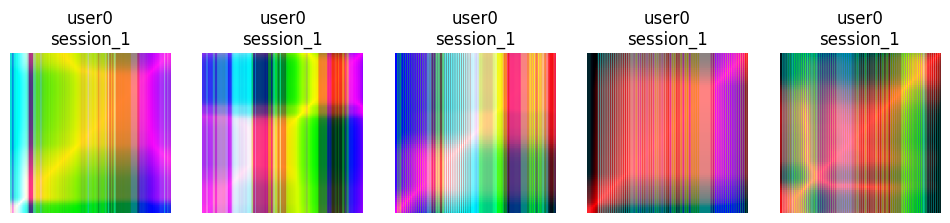


=== Visual Check (Last 5) ===


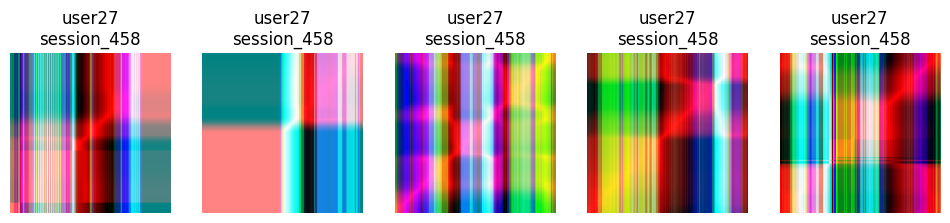


=== Session Continuity Check ===
Session transitions: 669

Check finished.


In [2]:
import os
import numpy as np
import matplotlib.pyplot as plt

# ======================================================
# CONFIG
# ======================================================

tensor_root = "ImagesTensors/ChaoShen/SRP_vx_vy/event150"   # 

num_users = 28
H = 224
W = 224

# ======================================================
# Load tensors
# ======================================================

img_path = os.path.join(tensor_root, "images.npy")
lab_path = os.path.join(tensor_root, "labels.npy")
ses_path = os.path.join(tensor_root, "sessions.npy")

print("Loading dataset...")

labels_raw = np.memmap(lab_path, dtype=np.uint8, mode="r")
N = labels_raw.size // num_users

images = np.memmap(
    img_path,
    dtype=np.uint8,
    mode="r",
    shape=(N, 3, H, W)
)

labels = labels_raw.reshape(N, num_users)

sessions = np.load(ses_path, allow_pickle=True)

print("Dataset size:", N)

# ======================================================
# 1 Shape check
# ======================================================

print("\n=== Shape Check ===")

print("Images shape:", images.shape)
print("Labels shape:", labels.shape)
print("Sessions shape:", sessions.shape)

assert images.shape[0] == labels.shape[0] == sessions.shape[0]

print("✓ Shapes aligned")

# ======================================================
# 2 Label sanity check
# ======================================================

print("\n=== Label Check ===")

label_sum = labels.sum(axis=1)

if not np.all(label_sum == 1):
    print("WARNING: Some samples not one-hot")
else:
    print("✓ All labels are one-hot")

# ======================================================
# 3 Ordering check
# ======================================================

print("\n=== Ordering Check ===")

for i in range(20):
    user = labels[i].argmax()
    print(i, "user", user, "session", sessions[i])

print("\n(If ordering correct, user should stay same for many rows)")

# ======================================================
# 4 Image value check
# ======================================================

print("\n=== Image Value Check ===")

print("Min pixel:", images.min())
print("Max pixel:", images.max())

# ======================================================
# 5 Visual check
# ======================================================

print("\n=== Visual Check (First 5) ===")

plt.figure(figsize=(12,3))

for i in range(5):

    img = images[i].transpose(1,2,0)
    user = labels[i].argmax()
    session = sessions[i]

    plt.subplot(1,5,i+1)
    plt.imshow(img[:, :, ::-1])
    plt.title(f"user{user}\n{session}")
    plt.axis("off")

plt.show()

print("\n=== Visual Check (Last 5) ===")

plt.figure(figsize=(12,3))

for i in range(5):

    idx = N - 5 + i

    img = images[idx].transpose(1,2,0)
    user = labels[idx].argmax()
    session = sessions[idx]

    plt.subplot(1,5,i+1)
    plt.imshow(img[:, :, ::-1])
    plt.title(f"user{user}\n{session}")
    plt.axis("off")

plt.show()

# ======================================================
# 6 Session continuity check
# ======================================================

print("\n=== Session Continuity Check ===")

changes = 0

for i in range(1, N):
    if sessions[i] != sessions[i-1]:
        changes += 1

print("Session transitions:", changes)

print("\nCheck finished.")

In [43]:
import os

root = "Images/Balabit/SRP_sota/event600"   # 改成你的路径

total_images = 0
user_counts = {}

for user in sorted(os.listdir(root)):
    user_path = os.path.join(root, user)

    if not os.path.isdir(user_path):
        continue

    count = 0

    for file in os.listdir(user_path):
        if file.lower().endswith((".png", ".jpg", ".jpeg")):
            count += 1

    user_counts[user] = count
    total_images += count

# ----------------------------
# print results
# ----------------------------
print("Per-user image count:")
for user, cnt in user_counts.items():
    print(f"{user}: {cnt}")

print("\n====================")
print(f"Total images: {total_images}")
print(f"Average images: {total_images/10}")

Per-user image count:
user12: 1620
user15: 978
user16: 1578
user20: 1936
user21: 816
user23: 809
user29: 853
user35: 642
user7: 2815
user9: 2745

Total images: 14792
Average images: 1479.2


Shape: (300, 300)
dtype: float32
min: 0.0
max: 0.8094216
mean: 0.23676191


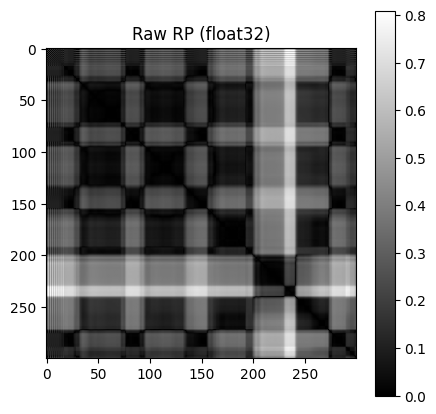


After mapping:
min: 0
max: 206
unique values (sample): [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19]


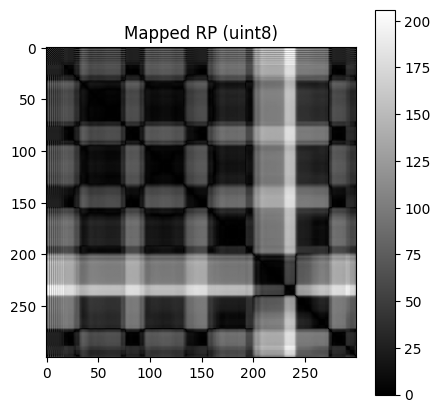

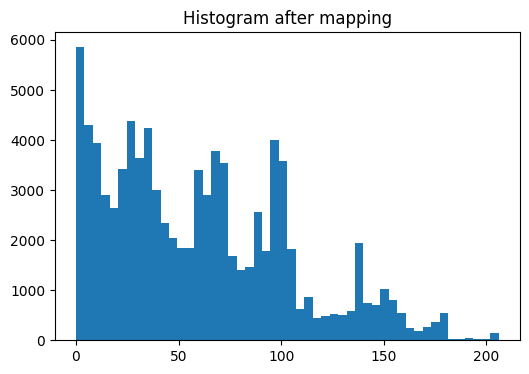

In [42]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# =========================================================
# 👉 修改这里：你的文件路径
# =========================================================
path = Path("ImagesTensors/Balabit/SRP_sota/event300/user16/session_0735651357-4.npy")

epsilon = 1

# =========================================================
# Load
# =========================================================
rp = np.load(path)

print("Shape:", rp.shape)
print("dtype:", rp.dtype)
print("min:", rp.min())
print("max:", rp.max())
print("mean:", rp.mean())

# =========================================================
# 👉 原始 SRP（float）
# =========================================================
plt.figure(figsize=(5,5))
plt.imshow(rp, cmap='gray')
plt.title("Raw RP (float32)")
plt.colorbar()
plt.show()

# =========================================================
# 👉 你的“断层 mapping”
# =========================================================
mask = (rp >= epsilon - 1e-8)

img = rp.copy()

# recurrence: 0~0.3 → 0~76
img[~mask] = img[~mask] * 255.0

# non-recur → 255
img[mask] = 255.0

img_uint8 = img.astype(np.uint8)

print("\nAfter mapping:")
print("min:", img_uint8.min())
print("max:", img_uint8.max())
print("unique values (sample):", np.unique(img_uint8)[:20])

# =========================================================
# 👉 显示映射后图像
# =========================================================
plt.figure(figsize=(5,5))
plt.imshow(img_uint8, cmap='gray')
plt.title("Mapped RP (uint8)")
plt.colorbar()
plt.show()

# =========================================================
# 👉 Histogram（最关键！！！）
# =========================================================
plt.figure(figsize=(6,4))
plt.hist(img_uint8.flatten(), bins=50)
plt.title("Histogram after mapping")
plt.show()